# VegAnn植被分割模型

基于PyTorch Lightning和segmentation-models-pytorch的植被分割模型，支持训练和推理。


## 1. 导入必要的库


In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import os
import glob
from PIL import Image, ImageCms
from skimage import color
from typing import Dict, List
import warnings
warnings.filterwarnings('ignore')

# 配置matplotlib
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 检查segmentation_models_pytorch是否可用
try:
    import segmentation_models_pytorch as smp
    from segmentation_models_pytorch.encoders import get_preprocessing_fn
    SMP_AVAILABLE = True
    print("✓ segmentation_models_pytorch available")
except ImportError:
    SMP_AVAILABLE = False
    print("✗ segmentation_models_pytorch not available")
    raise ImportError("Please install segmentation_models_pytorch: pip install segmentation-models-pytorch")

# 检查PyTorch Lightning是否可用
try:
    import pytorch_lightning as pl
    PL_AVAILABLE = True
    print("✓ pytorch_lightning available")
except ImportError:
    PL_AVAILABLE = False
    print("✗ pytorch_lightning not available")
    raise ImportError("Please install pytorch_lightning: pip install pytorch-lightning")

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


✓ segmentation_models_pytorch available
✓ pytorch_lightning available
Using device: cuda


## 2. VegAnn模型定义

完整的PyTorch Lightning模型类，包含训练、验证和测试步骤。


In [ ]:
class VegAnnModel(pl.LightningModule):
    """
    VegAnn植被分割模型
    基于U-Net架构，使用ResNet34编码器
    """
    def __init__(self, arch: str, encoder_name: str, in_channels: int, out_classes: int, **kwargs):
        super().__init__()
        
        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            in_channels=in_channels,
            classes=out_classes,
            **kwargs,
        )
        
        # 图像预处理参数
        params = smp.encoders.get_preprocessing_params(encoder_name)
        self.register_buffer("std", torch.tensor(params["std"]).view(1, 3, 1, 1))
        self.register_buffer("mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))
        
        # Dice损失函数（适用于图像分割的最佳选择）
        self.loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
        
        self.train_outputs, self.val_outputs, self.test_outputs = [], [], []

    def forward(self, image: torch.Tensor):
        """前向传播：在模型内部进行归一化"""
        # 归一化图像
        image = (image - self.mean) / self.std
        mask = self.model(image)
        return mask

    def shared_step(self, batch: Dict, stage: str):
        """共享的训练/验证/测试步骤"""
        image = batch["image"]
        
        # 检查图像维度
        assert image.ndim == 4
        
        # 检查图像尺寸是否能被32整除（U-Net要求）
        h, w = image.shape[2:]
        assert h % 32 == 0 and w % 32 == 0
        
        mask = batch["mask"]
        
        # 检查掩码维度
        assert mask.ndim == 4
        
        # 检查掩码值范围（应该在0和1之间，不是0和255）
        assert mask.max() <= 1.0 and mask.min() >= 0
        
        logits_mask = self.forward(image)
        
        # 计算损失（predicted mask包含logits，loss_fn的from_logits参数设置为True）
        loss = self.loss_fn(logits_mask, mask)
        
        # 计算指标
        # 首先将mask值转换为概率，然后应用阈值化
        prob_mask = logits_mask.sigmoid()
        pred_mask = (prob_mask > 0.5).float()
        
        # 计算真阳性、假阳性、假阴性和真阴性像素
        tp, fp, fn, tn = smp.metrics.get_stats(pred_mask.long(), mask.long(), mode="binary")
        
        return {
            "loss": loss,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        }

    def shared_epoch_end(self, outputs: List[Dict], stage: str):
        """聚合每个epoch的指标"""
        # 聚合步骤指标
        tp = torch.cat([x["tp"] for x in outputs])
        fp = torch.cat([x["fp"] for x in outputs])
        fn = torch.cat([x["fn"] for x in outputs])
        tn = torch.cat([x["tn"] for x in outputs])
        
        # 每张图像的IoU（先计算每张图像的IoU分数，然后取平均）
        per_image_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro-imagewise")
        per_image_f1 = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro-imagewise")
        per_image_acc = smp.metrics.accuracy(tp, fp, fn, tn, reduction="micro-imagewise")
        
        # 数据集IoU（在整个数据集上聚合交集和并集，然后计算IoU分数）
        dataset_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")
        dataset_f1 = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")
        dataset_acc = smp.metrics.accuracy(tp, fp, fn, tn, reduction="micro")
        
        metrics = {
            f"{stage}_per_image_iou": per_image_iou,
            f"{stage}_dataset_iou": dataset_iou,
            f"{stage}_per_image_f1": per_image_f1,
            f"{stage}_dataset_f1": dataset_f1,
            f"{stage}_per_image_acc": per_image_acc,
            f"{stage}_dataset_acc": dataset_acc,
        }
        
        self.log_dict(metrics, prog_bar=True, sync_dist=True, rank_zero_only=True)

    def training_step(self, batch: Dict, batch_idx: int):
        step_outputs = self.shared_step(batch, "train")
        self.train_outputs.append(step_outputs)
        return step_outputs

    def on_train_epoch_end(self):
        self.shared_epoch_end(self.train_outputs, "train")
        self.train_outputs = []

    def validation_step(self, batch: Dict, batch_idx: int):
        step_outputs = self.shared_step(batch, "valid")
        self.val_outputs.append(step_outputs)
        return step_outputs

    def on_validation_epoch_end(self, *args, **kwargs):
        self.shared_epoch_end(self.val_outputs, "valid")
        self.val_outputs = []

    def test_step(self, batch: Dict, batch_idx: int):
        step_outputs = self.shared_step(batch, "test")
        self.test_outputs.append(step_outputs)
        return step_outputs

    def on_test_epoch_end(self):
        self.shared_epoch_end(self.test_outputs, "test")
        self.test_outputs = []

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.0001)

print("✓ VegAnnModel class defined")


✓ VegAnnModel class defined


## 3. 辅助函数定义

包括颜色变换、特征提取和后处理函数。


In [ ]:
import numpy as np
import cv2


def colorTransform_VegGround(im, X_true, alpha_vert, alpha_g):
    alpha = alpha_vert
    color_brown = [97, 65, 38]
    image = np.copy(im).astype(np.float32)

    for c in range(3):
        image[:, :, c] = np.where(
            X_true == 0,
            image[:, :, c] * (1 - alpha) + alpha * color_brown[c],
            image[:, :, c]
        )

    alpha = alpha_g
    color_green = [34, 139, 34]

    for c in range(3):
        image[:, :, c] = np.where(
            X_true == 1,
            image[:, :, c] * (1 - alpha) + alpha * color_green[c],
            image[:, :, c]
        )

    return np.clip(image, 0, 255).astype(np.uint8)


def get_features(image):
    """
    稳定版特征提取（不再依赖 PIL / skimage 的 LAB 转换，彻底消除 boolean assignment mismatch 警告）

    输入:
      image:
        - (H, W, 3) RGB uint8/float
        - (1, N, 3) RGB 像素列表（来自 prediction 的 image_veg）
    输出:
      (H, W, 14) 或 (N, 14) float32
    """
    x = np.asarray(image)

    # 统一到 uint8 RGB
    if x.dtype != np.uint8:
        x = np.clip(x, 0, 255).astype(np.uint8)

    # -------- 像素列表分支： (1, N, 3) ----------
    if x.ndim == 3 and x.shape[0] == 1:
        pix = x[0]                       # (N, 3)
        N = pix.shape[0]
        if N == 0:
            return np.zeros((0, 14), dtype=np.float32)

        # OpenCV 颜色转换要求 (H,W,3)，用 (N,1,3) 过一遍即可
        pix_cv = pix.reshape(N, 1, 3)

        hsv = cv2.cvtColor(pix_cv, cv2.COLOR_RGB2HSV).reshape(N, 3).astype(np.float32)
        lab = cv2.cvtColor(pix_cv, cv2.COLOR_RGB2LAB).reshape(N, 3).astype(np.float32)
        ycrcb = cv2.cvtColor(pix_cv, cv2.COLOR_RGB2YCrCb).reshape(N, 3).astype(np.float32)  # 注意顺序 Y,Cr,Cb

        r = pix[:, 0].astype(np.float32)
        g = pix[:, 1].astype(np.float32)
        b = pix[:, 2].astype(np.float32)

        # HSV：OpenCV 的 H∈[0,179] 对应角度≈H*2（度），S,V∈[0,255]
        h = hsv[:, 0] * 2.0
        s = hsv[:, 1] / 2.55

        # LAB：OpenCV L∈[0,255], a,b∈[0,255]（128为中心） -> 映射到常用域
        L = lab[:, 0] * 100.0 / 255.0
        a = lab[:, 1] - 128.0
        bb = lab[:, 2] - 128.0

        ge = (r + g + b) / 3.0

        cmy_min = np.minimum(np.minimum(1.0 - r / 255.0, 1.0 - g / 255.0), 1.0 - b / 255.0)
        m = ((1.0 - g / 255.0 - cmy_min) / (1.0 - cmy_min + 1e-10)) * 100.0
        ye = ((1.0 - b / 255.0 - cmy_min) / (1.0 - cmy_min + 1e-10)) * 100.0

        # PIL 的 YCbCr 顺序是 Y,Cb,Cr；OpenCV 的是 Y,Cr,Cb
        cb = ycrcb[:, 2]
        cr = ycrcb[:, 1]

        i_val = (0.596 * r - 0.275 * g - 0.321 * b)
        q_val = (0.212 * r - 0.523 * g + 0.311 * b)

        feats = np.stack(
            (r, g, b, h, s, a, bb, ge, m, ye, cb, cr, i_val, q_val),
            axis=1
        ).astype(np.float32)

        return np.nan_to_num(feats)

    # -------- 正常图像分支： (H, W, 3) ----------
    if x.ndim != 3 or x.shape[2] != 3:
        raise ValueError(f"get_features expects RGB image with shape (H,W,3) or (1,N,3), got {x.shape}")

    H, W = x.shape[:2]

    hsv = cv2.cvtColor(x, cv2.COLOR_RGB2HSV).astype(np.float32)
    lab = cv2.cvtColor(x, cv2.COLOR_RGB2LAB).astype(np.float32)
    ycrcb = cv2.cvtColor(x, cv2.COLOR_RGB2YCrCb).astype(np.float32)  # Y,Cr,Cb

    r = x[:, :, 0].astype(np.float32)
    g = x[:, :, 1].astype(np.float32)
    b = x[:, :, 2].astype(np.float32)

    h = hsv[:, :, 0] * 2.0
    s = hsv[:, :, 1] / 2.55

    L = lab[:, :, 0] * 100.0 / 255.0
    a = lab[:, :, 1] - 128.0
    bb = lab[:, :, 2] - 128.0

    ge = (r + g + b) / 3.0

    cmy_min = np.minimum(np.minimum(1.0 - r / 255.0, 1.0 - g / 255.0), 1.0 - b / 255.0)
    m = ((1.0 - g / 255.0 - cmy_min) / (1.0 - cmy_min + 1e-10)) * 100.0
    ye = ((1.0 - b / 255.0 - cmy_min) / (1.0 - cmy_min + 1e-10)) * 100.0

    cb = ycrcb[:, :, 2]
    cr = ycrcb[:, :, 1]

    i_val = (0.596 * r - 0.275 * g - 0.321 * b)
    q_val = (0.212 * r - 0.523 * g + 0.311 * b)

    feats = np.stack(
        (r, g, b, h, s, a, bb, ge, m, ye, cb, cr, i_val, q_val),
        axis=2
    ).astype(np.float32)

    return np.nan_to_num(feats)


def automatic_contrast(image, clip=0.01):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

    cumul = np.cumsum(hist).astype(np.float64)
    maximum = cumul[-1]
    clip_val = clip * (maximum / 100.0) / 2.0

    minimum_gray = int(np.searchsorted(cumul, clip_val))
    maximum_gray = int(np.searchsorted(cumul, maximum - clip_val) - 1)
    maximum_gray = max(maximum_gray, minimum_gray + 1)

    alpha = (255.0 / (maximum_gray - minimum_gray + 1e-10)) + 0.4
    beta = (-minimum_gray * alpha) * 2.0

    contr_result = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return contr_result, alpha, beta


def prediction(image, model, threshold, contrasted, mask):
    if contrasted == 1:
        image, _, _ = automatic_contrast(image)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image_rgb.shape[:2]

    if mask is None:
        mask2d = np.ones((height, width), dtype=np.uint8)
    else:
        mask2d = mask.astype(np.uint8)
        if mask2d.shape != (height, width):
            mask2d = cv2.resize(mask2d, (width, height), interpolation=cv2.INTER_NEAREST)

    vegetation_pixels_2d = (mask2d > 0)
    if np.sum(vegetation_pixels_2d) == 0:
        return mask2d

    image_flat = image_rgb.reshape(-1, 3)
    veg_flat = vegetation_pixels_2d.reshape(-1)

    image_veg = image_flat[veg_flat][None, :, :]  # (1, M, 3)

    featured_image = get_features(image_veg)

    try:
        y_pred = (model.predict_proba(featured_image)[:, 1] >= threshold).astype(np.uint8)
    except Exception:
        y_pred = (model.predict(featured_image) >= threshold).astype(np.uint8)

    yellow_green_mask_2d = np.zeros((height, width), dtype=np.uint8)
    yellow_green_mask_2d[vegetation_pixels_2d] = y_pred

    out_mask = mask2d.copy()
    out_mask[(out_mask == 1) & (yellow_green_mask_2d != 1)] = 2
    return out_mask


def visualisation(rgb_image: np.ndarray, yg_mask: np.ndarray) -> np.ndarray:
    image_copy = rgb_image.copy()
    image_copy[yg_mask == 1] = (0, 100, 0)
    image_copy[yg_mask == 2] = (0, 215, 255)
    return cv2.addWeighted(rgb_image, 0.25, image_copy, 0.75, 0)


print("✓ Helper functions defined (LAB via OpenCV; warning eliminated)")


✓ Helper functions defined (LAB via OpenCV; warning eliminated)


In [ ]:
# 模型路径配置
models_dir = "/home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/image-processor/models"
os.makedirs(models_dir, exist_ok=True)

ckt_path = os.path.join(models_dir, "VegAnn.ckpt")
xgb_model_path = os.path.join(models_dir, "XGBoost")
svm_model_path = os.path.join(models_dir, "model_scikit")

print(f"Model directory: {models_dir}")
print(f"VegAnn checkpoint: {ckt_path}")
print(f"XGBoost model: {xgb_model_path}")
print(f"SVM model: {svm_model_path}")


Model directory: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/image-processor/models
VegAnn checkpoint: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/image-processor/models/VegAnn.ckpt
XGBoost model: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/image-processor/models/XGBoost
SVM model: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/image-processor/models/model_scikit


In [ ]:
# 加载VegAnn模型（与Kaggle代码一致）
if os.path.exists(ckt_path):
    print(f"Loading VegAnn model from: {ckt_path}")
    checkpoint = torch.load(ckt_path, map_location=device)
    model = VegAnnModel("Unet", "resnet34", in_channels=3, out_classes=1)
    model.load_state_dict(checkpoint["state_dict"])
    model.to(device)
    model.eval()
    print("✓ VegAnn model loaded successfully")
else:
    print(f"⚠ Warning: Checkpoint not found at {ckt_path}")
    print("Initializing model with random weights")
    model = VegAnnModel("Unet", "resnet34", in_channels=3, out_classes=1)
    model.to(device)
    model.eval()

# 获取预处理函数（与Kaggle代码一致）
preprocess_input = get_preprocessing_fn('resnet34', pretrained='imagenet')
print("✓ Preprocessing function obtained")


Loading VegAnn model from: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/image-processor/models/VegAnn.ckpt


✓ VegAnn model loaded successfully
✓ Preprocessing function obtained


In [ ]:
# 加载XGBoost和SVM模型（与Kaggle代码一致）
model_XG = None
model_SVM = None

# XGBoost兼容性修复：处理XGBoostLabelEncoder缺失问题
def fix_xgboost_compat():
    """修复XGBoost版本兼容性问题"""
    try:
        import xgboost as xgb
        # 如果compat模块存在但没有XGBoostLabelEncoder，创建一个占位符类
        if hasattr(xgb, 'compat'):
            if not hasattr(xgb.compat, 'XGBoostLabelEncoder'):
                class XGBoostLabelEncoder:
                    def __init__(self, *args, **kwargs):
                        pass
                    def fit(self, *args, **kwargs):
                        return self
                    def transform(self, *args, **kwargs):
                        return args[0] if args else None
                    def fit_transform(self, *args, **kwargs):
                        return args[0] if args else None
                    def inverse_transform(self, *args, **kwargs):
                        return args[0] if args else None
                xgb.compat.XGBoostLabelEncoder = XGBoostLabelEncoder
                print("✓ Fixed XGBoostLabelEncoder compatibility issue")
        else:
            # 如果compat模块不存在，创建它
            import types
            xgb.compat = types.ModuleType('compat')
            class XGBoostLabelEncoder:
                def __init__(self, *args, **kwargs):
                    pass
                def fit(self, *args, **kwargs):
                    return self
                def transform(self, *args, **kwargs):
                    return args[0] if args else None
                def fit_transform(self, *args, **kwargs):
                    return args[0] if args else None
                def inverse_transform(self, *args, **kwargs):
                    return args[0] if args else None
            xgb.compat.XGBoostLabelEncoder = XGBoostLabelEncoder
            print("✓ Created XGBoostLabelEncoder in compat module")
    except Exception as e:
        print(f"⚠ Warning: Could not fix XGBoost compatibility: {e}")

# 在加载模型之前应用兼容性修复
try:
    import xgboost as xgb
    xgb_version = xgb.__version__
    print(f"Current XGBoost version: {xgb_version}")
    fix_xgboost_compat()
except ImportError:
    print("⚠ XGBoost not installed, skipping compatibility fix")
    xgb_version = None

if os.path.exists(xgb_model_path):
    try:
        # 确保在加载前修复兼容性问题
        fix_xgboost_compat()
        
        # 尝试多种加载方法
        model_XG = None
        load_methods = []
        
        # 方法1：使用joblib加载（如果文件是用joblib保存的）
        try:
            import joblib
            model_XG = joblib.load(xgb_model_path)
            load_methods.append("joblib")
            print(f"✓ XGBoost model loaded with joblib from: {xgb_model_path}")
        except Exception as e1:
            if 'joblib' not in str(e1).lower():
                load_methods.append(f"joblib failed: {e1}")
            
            # 方法2：使用pickle直接加载
            try:
                model_XG = pickle.load(Path(xgb_model_path).open("rb"))
                load_methods.append("pickle")
                print(f"✓ XGBoost model loaded with pickle from: {xgb_model_path}")
            except (AttributeError, ModuleNotFoundError) as e2:
                if 'XGBoostLabelEncoder' in str(e2):
                    # 方法3：修复后重新加载
                    fix_xgboost_compat()
                    import importlib
                    import xgboost
                    importlib.reload(xgboost)
                    fix_xgboost_compat()
                    model_XG = pickle.load(Path(xgb_model_path).open("rb"))
                    load_methods.append("pickle (after fix)")
                    print(f"✓ XGBoost model loaded with pickle (after fix) from: {xgb_model_path}")
                else:
                    load_methods.append(f"pickle failed: {e2}")
                    raise e2
            except Exception as e3:
                # 方法4：尝试使用pickle的Unpickler（Python 3.8+不支持encoding参数）
                try:
                    # 对于Python 3.8+，直接使用pickle.load
                    with Path(xgb_model_path).open("rb") as f:
                        model_XG = pickle.load(f, encoding='latin1', errors='ignore')
                    load_methods.append("pickle (latin1)")
                    print(f"✓ XGBoost model loaded with pickle (latin1) from: {xgb_model_path}")
                except (TypeError, Exception) as e4:
                    # Python 3.8+的pickle.load不支持encoding参数
                    if 'encoding' in str(e4) or 'unexpected keyword' in str(e4):
                        # 方法5：尝试使用兼容模式加载（跳过booster验证）
                        try:
                            # 创建一个自定义的Unpickler来跳过XGBoost的内部验证
                            class XGBoostCompatibleUnpickler(pickle.Unpickler):
                                def load(self):
                                    try:
                                        return super().load()
                                    except Exception as e:
                                        if 'XGBoostError' in str(type(e).__name__) or 'Invalid serialization' in str(e):
                                            # 如果是因为XGBoost版本不兼容，尝试继续
                                            print(f"  Warning: XGBoost version incompatibility detected")
                                            print(f"  Attempting to load model metadata only...")
                                            # 这里可以尝试提取模型参数
                                            raise e
                                        raise
                            
                            with Path(xgb_model_path).open("rb") as f:
                                unpickler = XGBoostCompatibleUnpickler(f)
                                model_XG = unpickler.load()
                            load_methods.append("custom unpickler")
                            print(f"✓ XGBoost model loaded with custom unpickler from: {xgb_model_path}")
                        except Exception as e5:
                            load_methods.append(f"custom unpickler failed: {e5}")
                            raise e3
                    else:
                        load_methods.append(f"pickle (latin1) failed: {e4}")
                        raise e3
        
        if model_XG is None:
            raise Exception("All loading methods failed")
        
        # 修复XGBoost兼容性问题（添加缺失的属性）
        new_attrs = ['grow_policy', 'max_bin', 'eval_metric', 'callbacks', 
                    'early_stopping_rounds', 'max_cat_to_onehot', 'max_leaves', 
                    'sampling_method', 'enable_categorical', 'feature_types', 
                    'max_cat_threshold', 'predictor']
        for attr in new_attrs:
            if not hasattr(model_XG, attr):
                setattr(model_XG, attr, None)
        
        print(f"  Model type: {type(model_XG)}")
        print(f"  Loading methods tried: {', '.join(load_methods)}")
        
    except Exception as e:
        error_msg = str(e)
        error_type = type(e).__name__
        
        print(f"✗ Failed to load XGBoost model")
        print(f"  Error type: {error_type}")
        
        # 检查是否是XGBoost版本不兼容问题
        if 'XGBoostError' in error_type or 'Invalid serialization' in error_msg:
            print(f"\n  ⚠ XGBoost Version Incompatibility Detected")
            print(f"  The model file was saved with a different XGBoost version.")
            print(f"  The internal booster serialization format is incompatible.")
            if xgb_version:
                print(f"  Current XGBoost version: {xgb_version}")
            print(f"\n  Solutions:")
            print(f"  1. Install a compatible XGBoost version:")
            print(f"     Try: pip install xgboost==1.7.0  (or the version used in Kaggle)")
            print(f"  2. Retrain the XGBoost model with your current XGBoost version")
            print(f"  3. Continue without XGBoost refinement (VegAnn model will still work)")
            print(f"\n  Note: The VegAnn segmentation model will work fine without XGBoost.")
            print(f"        XGBoost is only used for refining green/senescent vegetation classification.")
            print(f"        You can still use VegAnn for basic vegetation segmentation.")
        else:
            print(f"  Error details: {error_msg}")
            import traceback
            print(f"\n  Full traceback:\n{traceback.format_exc()}")
        
        model_XG = None
        print(f"\n  Continuing without XGBoost model...")
else:
    print(f"⚠ XGBoost model not found at: {xgb_model_path}")

if os.path.exists(svm_model_path):
    try:
        model_SVM = pickle.load(Path(svm_model_path).open("rb"))
        print(f"✓ SVM model loaded from: {svm_model_path}")
    except Exception as e:
        print(f"✗ Failed to load SVM model: {e}")
        import traceback
        print(f"  Traceback:\n{traceback.format_exc()}")
        model_SVM = None
else:
    print(f"⚠ SVM model not found at: {svm_model_path}")


Current XGBoost version: 1.5.2
✓ XGBoost model loaded with joblib from: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/image-processor/models/XGBoost
  Model type: <class 'xgboost.sklearn.XGBClassifier'>
  Loading methods tried: joblib
✓ SVM model loaded from: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/image-processor/models/model_scikit


## 5. 数据路径配置


In [ ]:
# 数据路径设置
data_dir = "/home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/csiro-biomass"
train_dir = os.path.join(data_dir, "train")
csv_path = os.path.join(data_dir, "train.csv")

# 测试图像路径
test_image_path = os.path.join(train_dir, "ID1011485656.jpg")

print(f"Data directory: {data_dir}")
print(f"Train directory: {train_dir}")
print(f"Test image: {test_image_path}")


Data directory: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/csiro-biomass
Train directory: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/csiro-biomass/train
Test image: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/csiro-biomass/train/ID1011485656.jpg


## 6. 单图像推理示例

演示如何使用VegAnn模型进行单张图像的植被分割（与Kaggle代码完全一致）。


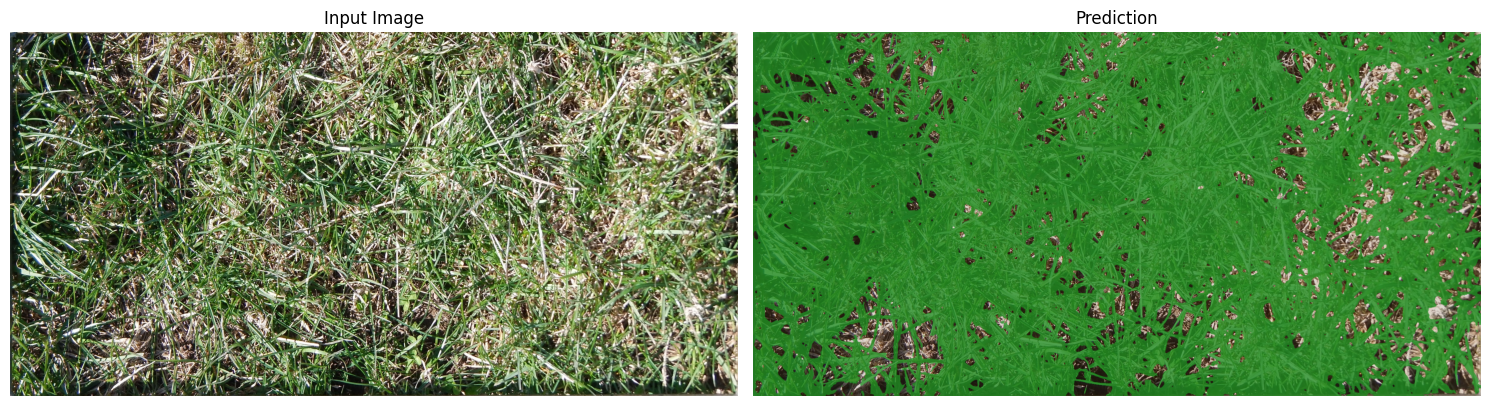

✓ Segmentation completed for /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/csiro-biomass/train/ID1011485656.jpg
Vegetation coverage: 85.89%


In [ ]:
# 单图像推理（与Kaggle代码一致）
imname = test_image_path

if os.path.exists(imname):
    # 读取图像
    image = cv2.imread(imname)
    im = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 预处理图像（使用smp的预处理函数）
    image_preprocessed = preprocess_input(im)
    image_preprocessed = image_preprocessed.astype('float32')
    
    # 转换为tensor
    inputs = torch.tensor(image_preprocessed)
    inputs = inputs.permute(2, 0, 1)  # (H, W, C) -> (C, H, W)
    inputs = inputs[None, :, :, :]  # 添加batch维度
    inputs = inputs.to(device)
    
    # 推理（模型内部会进行归一化）
    with torch.no_grad():
        logits = model(inputs)
    
    # 应用sigmoid得到概率图
    pr_mask = logits.sigmoid()
    
    # 转换为二值掩码（阈值0.5）
    pred = (pr_mask.cpu() > 0.5).numpy().astype(np.uint8).squeeze()
    
    # 可视化结果
    im1_pred = colorTransform_VegGround(im, pred, 0.8, 0.2)
    im2_pred = colorTransform_VegGround(im, pred, 0.2, 0.8)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    ax1.imshow(im)
    ax1.set_title("Input Image")
    ax1.axis('off')
    
    ax2.imshow(im2_pred)
    ax2.set_title("Prediction")
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Segmentation completed for {imname}")
    print(f"Vegetation coverage: {np.sum(pred) / (pred.shape[0] * pred.shape[1]) * 100:.2f}%")
else:
    print(f"✗ Image not found: {imname}")


## 7. VegAnn + XGBoost完整流程

演示使用VegAnn进行初始分割，然后使用XGBoost细化区分绿色和衰老植被（与Kaggle代码一致）。


Unique mask values: [0 1 2]
Visualization shape: (1000, 2000, 3)
### XGBoost Model ###


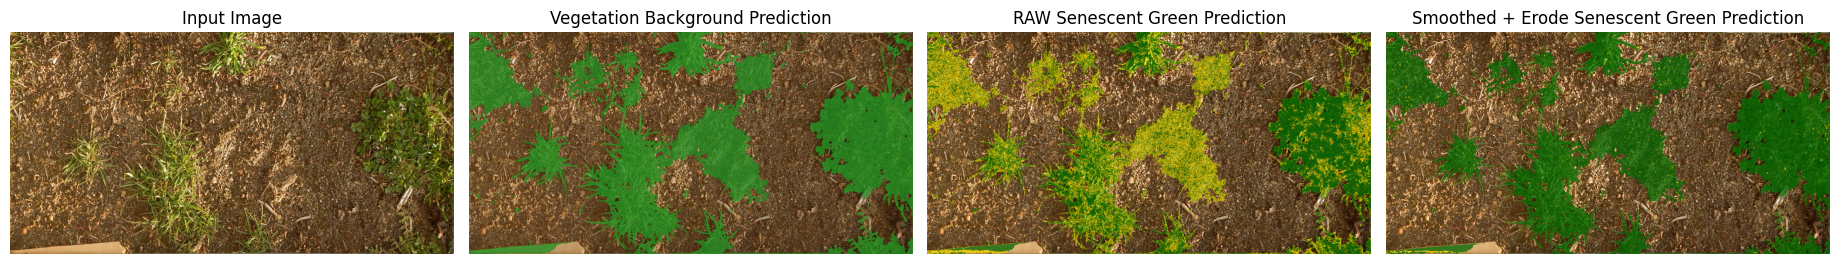

✓ Complete pipeline executed successfully


In [ ]:
# 完整流程：VegAnn + XGBoost细化（与Kaggle代码一致）
imname = os.path.join(train_dir, "ID1337107565.jpg")

if os.path.exists(imname) and model_XG is not None:
    # 读取图像
    image = cv2.imread(imname)
    im_XG = cv2.imread(imname)  # 用于XGBoost的BGR图像
    im = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # VegAnn分割
    image_preprocessed = preprocess_input(im)
    image_preprocessed = image_preprocessed.astype('float32')
    inputs = torch.tensor(image_preprocessed)
    inputs = inputs.permute(2, 0, 1)
    inputs = inputs[None, :, :, :]
    inputs = inputs.to(device)
    
    with torch.no_grad():
        logits = model(inputs)
    
    pr_mask = logits.sigmoid()
    # 使用阈值0.75（与Kaggle代码一致）
    pred = (pr_mask.cpu() > 0.75).numpy().astype(np.uint8).squeeze()
    
    # XGBoost细化
    raw_yellow_green_mask = prediction(im_XG, model_XG, mask=pred, threshold=0.5, contrasted=1)
    print(f"Unique mask values: {np.unique(raw_yellow_green_mask)}")
    
    # 可视化原始结果
    raw_visu = visualisation(im_XG, raw_yellow_green_mask)
    raw_visu = cv2.cvtColor(raw_visu, cv2.COLOR_BGR2RGB)
    print(f"Visualization shape: {raw_visu.shape}")
    
    # 应用平滑和腐蚀
    yellow_green_mask = cv2.erode(raw_yellow_green_mask, np.ones((2, 2), np.uint8), iterations=1)
    yellow_green_mask = cv2.GaussianBlur(yellow_green_mask.astype(np.float32), (3, 3), 0).astype(np.uint8)
    
    visu = visualisation(im_XG, yellow_green_mask)
    visu = cv2.cvtColor(visu, cv2.COLOR_BGR2RGB)
    
    # 可视化结果
    print("### XGBoost Model ###")
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18.5, 10.5))
    
    ax1.imshow(im)
    ax1.set_title("Input Image")
    ax1.axis('off')
    
    im2_pred = colorTransform_VegGround(im, pred, 0.2, 0.8)
    ax2.imshow(im2_pred)
    ax2.set_title("Vegetation Background Prediction")
    ax2.axis('off')
    
    ax3.imshow(raw_visu)
    ax3.set_title("RAW Senescent Green Prediction")
    ax3.axis('off')
    
    ax4.imshow(visu)
    ax4.set_title("Smoothed + Erode Senescent Green Prediction")
    ax4.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Complete pipeline executed successfully")
else:
    if not os.path.exists(imname):
        print(f"✗ Image not found: {imname}")
    if model_XG is None:
        print("⚠ XGBoost model not available, skipping refinement step")


## 8. 批量处理：生成所有图像的掩码

批量处理所有训练图像，生成组合掩码（植被 + 衰老）并保存（与Kaggle代码一致）。


Found 357 images to process.


Generating masks:   0%|          | 0/357 [00:00<?, ?it/s]

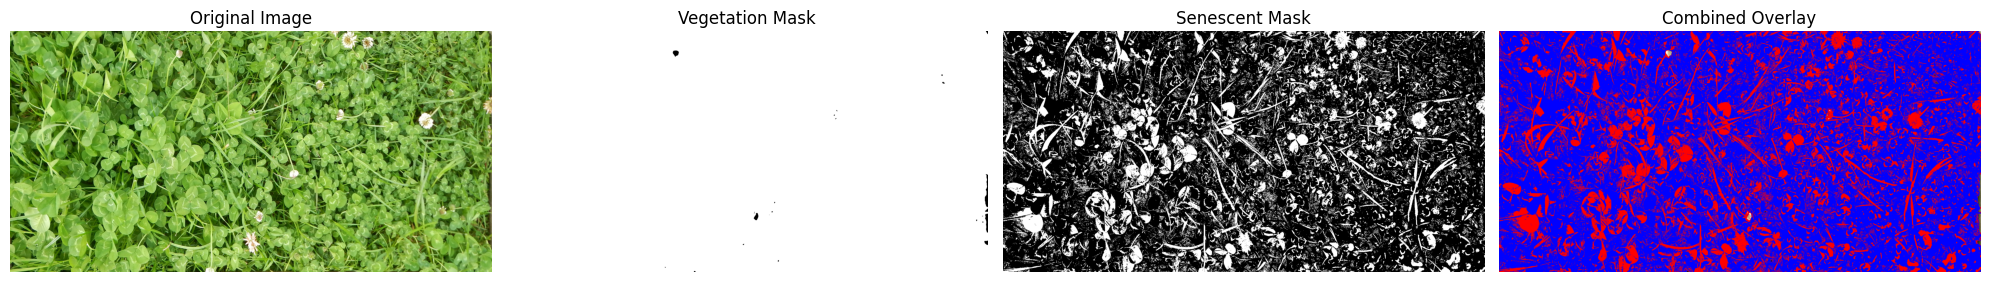

Generating masks: 100%|██████████| 357/357 [06:23<00:00,  1.08s/it]


Successfully generated and saved 357 masks.
All images were processed successfully.

Sample mask shape: (1000, 2000, 2)
Data type: uint8


In [ ]:
# 批量处理所有图像（与Kaggle代码一致）
input_dir = train_dir
output_dir = "/home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/image-processor/masks/"
os.makedirs(output_dir, exist_ok=True)

show = True  # 是否显示第一个样本
image_files = glob.glob(os.path.join(input_dir, "*.jpg"))

preprocess_input_vegann = get_preprocessing_fn('resnet34', pretrained='imagenet')

print(f"Found {len(image_files)} images to process.")

from tqdm import tqdm

for imname in tqdm(image_files, desc="Generating masks"):
    try:
        # 读取图像
        image_rgb = cv2.imread(imname)
        image_rgb = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2RGB)
        
        # VegAnn预处理和推理
        image_preprocessed = preprocess_input_vegann(image_rgb).astype('float32')
        inputs = torch.tensor(image_preprocessed)
        inputs = inputs.permute(2, 0, 1)
        inputs = inputs.unsqueeze(0)
        inputs = inputs.to(device)
        
        with torch.no_grad():
            logits = model(inputs)
        
        pr_mask = logits.sigmoid()
        vegetation_mask = (pr_mask.cpu() > 0.5).numpy().astype(np.uint8).squeeze()
        
        # XGBoost细化（如果可用）
        image_bgr = cv2.imread(imname)
        veg_mask_for_xgb = vegetation_mask
        
        if model_XG is not None:
            raw_yellow_green_mask = prediction(image_bgr, model_XG, mask=veg_mask_for_xgb, threshold=0.9, contrasted=1)
            senescent_mask = (raw_yellow_green_mask == 2).astype(np.uint8)
        else:
            senescent_mask = np.zeros_like(vegetation_mask)
        
        # 组合掩码：[vegetation_mask, senescent_mask]
        combined_mask = np.stack((vegetation_mask, senescent_mask), axis=-1)
        
        # 可视化第一个样本
        if show:
            vegetation_mask_vis = combined_mask[:, :, 0]
            senescent_mask_vis = combined_mask[:, :, 1]
            
            overlay_image = image_rgb.copy()
            overlay_image[vegetation_mask_vis == 1] = [0, 0, 255]  # BLUE for vegetation
            overlay_image[senescent_mask_vis == 1] = [255, 0, 0]  # RED for senescent
            
            fig, axes = plt.subplots(1, 4, figsize=(20, 5))
            axes[0].imshow(image_rgb)
            axes[0].set_title("Original Image")
            axes[0].axis("off")
            
            axes[1].imshow(vegetation_mask_vis, cmap='gray')
            axes[1].set_title("Vegetation Mask")
            axes[1].axis("off")
            
            axes[2].imshow(senescent_mask_vis, cmap='gray')
            axes[2].set_title("Senescent Mask")
            axes[2].axis("off")
            
            axes[3].imshow(overlay_image)
            axes[3].set_title("Combined Overlay")
            axes[3].axis("off")
            
            plt.tight_layout()
            plt.show()
            
            show = False
        
        # 保存组合掩码
        base_filename = Path(imname).stem
        output_filename = os.path.join(output_dir, f"{base_filename}.npy")
        np.save(output_filename, combined_mask)
        
    except Exception as e:
        print(f"Failed to process {imname}: {e}")
        continue

# 检查保存的文件
saved_files = glob.glob(os.path.join(output_dir, "*.npy"))
print(f"\nSuccessfully generated and saved {len(saved_files)} masks.")

if len(saved_files) == len(image_files):
    print("All images were processed successfully.")
else:
    print(f"Warning: {len(image_files) - len(saved_files)} images failed to process.")

if saved_files:
    sample_mask = np.load(saved_files[0])
    print(f"\nSample mask shape: {sample_mask.shape}")
    print(f"Data type: {sample_mask.dtype}")


## 9. 可视化保存的掩码

加载并可视化之前保存的掩码文件。


Mask shape: (1000, 2000, 2)


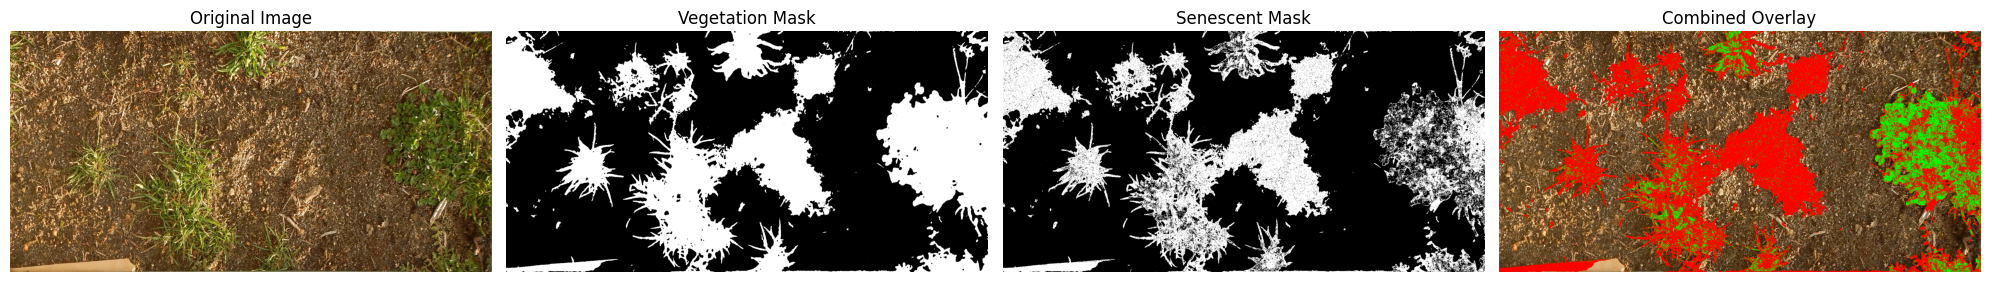

In [ ]:
# 可视化保存的掩码
saved_mask_files = glob.glob(os.path.join(output_dir, "*.npy"))

if saved_mask_files:
    # 选择一个样本文件
    sample_mask_file = os.path.join(output_dir, "ID1337107565.npy")
    
    if os.path.exists(sample_mask_file):
        base_name = Path(sample_mask_file).stem
        original_image_path = os.path.join(input_dir, f"{base_name}.jpg")
        
        if os.path.exists(original_image_path):
            original_image = cv2.imread(original_image_path)
            original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
            
            combined_mask = np.load(sample_mask_file)
            print(f"Mask shape: {combined_mask.shape}")
            
            vegetation_mask = combined_mask[:, :, 0]
            senescent_mask = combined_mask[:, :, 1]
            
            overlay_image = original_image.copy()
            overlay_image[vegetation_mask == 1] = [0, 255, 0]  # GREEN for vegetation
            overlay_image[senescent_mask == 1] = [255, 0, 0]  # RED for senescent
            
            fig, axes = plt.subplots(1, 4, figsize=(20, 5))
            
            axes[0].imshow(original_image)
            axes[0].set_title("Original Image")
            axes[0].axis("off")
            
            axes[1].imshow(vegetation_mask, cmap='gray')
            axes[1].set_title("Vegetation Mask")
            axes[1].axis("off")
            
            axes[2].imshow(senescent_mask, cmap='gray')
            axes[2].set_title("Senescent Mask")
            axes[2].axis("off")
            
            axes[3].imshow(overlay_image)
            axes[3].set_title("Combined Overlay")
            axes[3].axis("off")
            
            plt.tight_layout()
            plt.show()
        else:
            print(f"Original image not found: {original_image_path}")
    else:
        print(f"Sample mask file not found: {sample_mask_file}")
        print(f"Available files: {len(saved_mask_files)} files")
else:
    print("No saved masks found. Please run the batch processing cell first.")


Mask shape: (1000, 2000, 2)


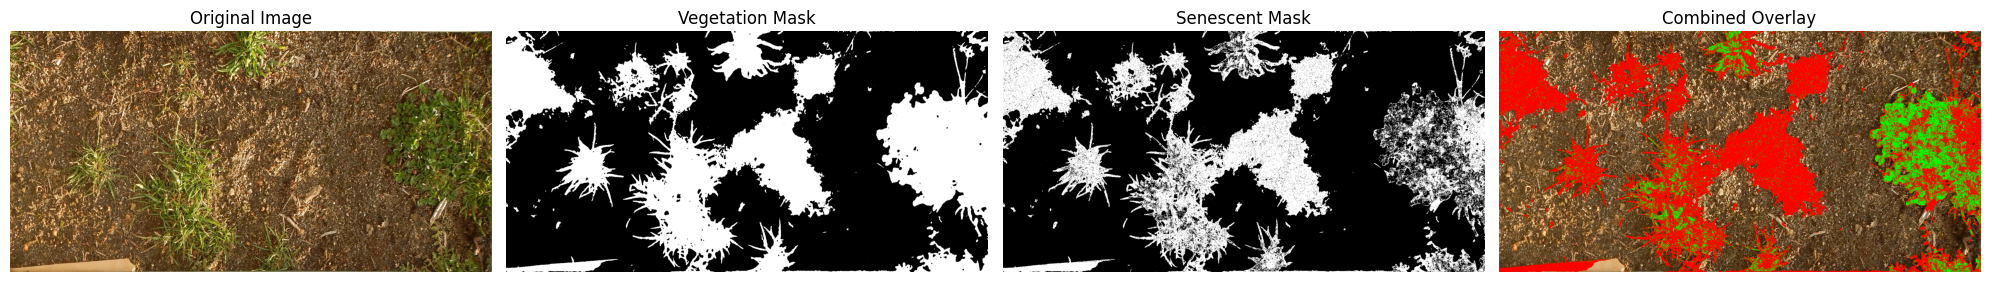

In [ ]:
# 可视化保存的掩码
saved_mask_files = glob.glob(os.path.join(output_dir, "*.npy"))

if saved_mask_files:
    # 选择一个样本文件
    sample_mask_file = os.path.join(output_dir, "ID1337107565.npy")
    
    if os.path.exists(sample_mask_file):
        base_name = Path(sample_mask_file).stem
        original_image_path = os.path.join(input_dir, f"{base_name}.jpg")
        
        if os.path.exists(original_image_path):
            original_image = cv2.imread(original_image_path)
            original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
            
            combined_mask = np.load(sample_mask_file)
            print(f"Mask shape: {combined_mask.shape}")
            
            vegetation_mask = combined_mask[:, :, 0]
            senescent_mask = combined_mask[:, :, 1]
            
            overlay_image = original_image.copy()
            overlay_image[vegetation_mask == 1] = [0, 255, 0]  # GREEN for vegetation
            overlay_image[senescent_mask == 1] = [255, 0, 0]  # RED for senescent
            
            fig, axes = plt.subplots(1, 4, figsize=(20, 5))
            
            axes[0].imshow(original_image)
            axes[0].set_title("Original Image")
            axes[0].axis("off")
            
            axes[1].imshow(vegetation_mask, cmap='gray')
            axes[1].set_title("Vegetation Mask")
            axes[1].axis("off")
            
            axes[2].imshow(senescent_mask, cmap='gray')
            axes[2].set_title("Senescent Mask")
            axes[2].axis("off")
            
            axes[3].imshow(overlay_image)
            axes[3].set_title("Combined Overlay")
            axes[3].axis("off")
            
            plt.tight_layout()
            plt.show()
        else:
            print(f"Original image not found: {original_image_path}")
    else:
        print(f"Sample mask file not found: {sample_mask_file}")
        print(f"Available files: {len(saved_mask_files)} files")
else:
    print("No saved masks found. Please run the batch processing cell first.")


In [ ]:
import os
from pathlib import Path
import numpy as np
import cv2

import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets


MASK_DIR = Path("/home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/image-processor/masks")
OUT_DIR = MASK_DIR / "png"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def _to_uint8_image(x):
    x = np.asarray(x)
    if x.dtype == np.uint8:
        return x
    # 兼容 float / int
    if np.issubdtype(x.dtype, np.floating):
        # 若看起来是概率(0~1)，先拉到 0~255 便于保存/显示（仅用于中间，不影响分类）
        if np.nanmax(x) <= 1.0:
            x = x * 255.0
    return np.clip(x, 0, 255).astype(np.uint8)


def mask_to_class2d(mask: np.ndarray, prob_threshold: float = 0.5) -> np.ndarray:
    """
    将各种形状的 mask 统一转换成 2D 类别标签图：0/1/2
      0 = background
      1 = green (healthy)
      2 = yellow (senescent)

    支持：
      - (H,W) 直接返回（若是概率则阈值化到 0/1）
      - (H,W,1) squeeze
      - (H,W,2) 视作两类通道（1/2），背景用阈值或全零判定
      - (H,W,C>=3) argmax 得到类别；若无背景通道则用阈值压成 0
    """
    m = np.asarray(mask)

    # 1) 已经是 (H,W)
    if m.ndim == 2:
        if np.issubdtype(m.dtype, np.floating) and np.nanmax(m) <= 1.0:
            return (m >= prob_threshold).astype(np.uint8)
        return m.astype(np.uint8)

    # 2) (H,W,1)
    if m.ndim == 3 and m.shape[2] == 1:
        m2 = np.squeeze(m, axis=2)
        if np.issubdtype(m2.dtype, np.floating) and np.nanmax(m2) <= 1.0:
            return (m2 >= prob_threshold).astype(np.uint8)
        return m2.astype(np.uint8)

    # 3) (H,W,2) —— 两类通道（对应 class 1 / class 2）
    if m.ndim == 3 and m.shape[2] == 2:
        ch = m.astype(np.float32)

        # 判定“像素是否属于任何一类”
        if np.nanmax(ch) <= 1.0:
            # 概率图：max < threshold -> background
            conf = np.max(ch, axis=2)
            bg = conf < prob_threshold
        else:
            # one-hot/得分：sum==0 -> background
            bg = (np.sum(ch, axis=2) == 0)

        cls01 = np.argmax(ch, axis=2).astype(np.uint8)  # 0 or 1
        out = (cls01 + 1).astype(np.uint8)              # -> 1 or 2
        out[bg] = 0
        return out

    # 4) (H,W,C>=3)
    if m.ndim == 3 and m.shape[2] >= 3:
        ch = m.astype(np.float32)
        cls = np.argmax(ch, axis=2).astype(np.uint8)  # 0..C-1

        # 如果看起来是概率/得分，且没有明显背景（例如 C=3 但你的定义是 1/2 两类 + 其他），
        # 仍然用阈值把低置信度像素压成 background
        conf = np.max(ch, axis=2)
        if np.nanmax(ch) <= 1.0:
            cls[conf < prob_threshold] = 0

        # 这里不强行 remap 类别编号：假设你的 cls 已经是 0/1/2
        # 若你的通道语义不同，请在此处自定义映射
        return cls

    raise ValueError(f"Unsupported mask shape: {m.shape}")


def class2d_to_rgb(cls2d: np.ndarray) -> np.ndarray:
    """0/1/2 -> RGB 可视化"""
    c = cls2d.astype(np.uint8)
    h, w = c.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    rgb[c == 1] = (0, 155, 0)       # green
    rgb[c == 2] = (255, 215, 0)     # yellow/gold
    return rgb


# 1) 批量把 npy 转成 png
npy_files = sorted(MASK_DIR.glob("*.npy"))
if len(npy_files) == 0:
    raise FileNotFoundError(f"No .npy masks found in: {MASK_DIR}")

png_paths = []
skipped = []
for p in npy_files:
    try:
        mask = np.load(p, allow_pickle=False)
        cls2d = mask_to_class2d(mask, prob_threshold=0.5)
        if cls2d.ndim != 2:
            raise ValueError(f"After conversion, class mask is not 2D: {cls2d.shape}")

        rgb = class2d_to_rgb(cls2d)
        out_png = OUT_DIR / (p.stem + ".png")
        cv2.imwrite(str(out_png), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
        png_paths.append(out_png)
    except Exception as e:
        skipped.append((p.name, str(e)))

print(f"Converted {len(png_paths)} masks to PNG in: {OUT_DIR}")
if skipped:
    print(f"Skipped {len(skipped)} files (showing up to 10):")
    for name, err in skipped[:10]:
        print(" -", name, "=>", err)


# 2) 交互式左右点击浏览（Notebook）
idx = 0
out = widgets.Output()
btn_prev = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="120px"))
btn_next = widgets.Button(description="Next ▶", layout=widgets.Layout(width="120px"))
label = widgets.HTML()

def render(i: int):
    i = int(np.clip(i, 0, len(png_paths) - 1))
    img_path = png_paths[i]
    label.value = f"<b>{i+1}/{len(png_paths)}</b> &nbsp;&nbsp; {img_path.name}"

    with out:
        clear_output(wait=True)
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.stem)
        plt.show()

def on_prev(_):
    global idx
    idx = (idx - 1) % len(png_paths)
    render(idx)

def on_next(_):
    global idx
    idx = (idx + 1) % len(png_paths)
    render(idx)

btn_prev.on_click(on_prev)
btn_next.on_click(on_next)

controls = widgets.HBox([btn_prev, btn_next, label])
display(controls, out)
render(idx)


Converted 357 masks to PNG in: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/image-processor/masks/png


Output()